### Assess Recovery

In [1]:
import os, sys, time


import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl  
from astropy.io import fits

from scipy.special import erfc # to calculate false positive , What's the chance that random noise could fake a CPD signal of this brightness?

sys.path.append(r"d:\CPD_MPIA\HPC_scripts\Source_codes\diskdictionary_r90")
import diskdictionaryr0_5 as disk


In [2]:
# target disk/gap; iteration
target, gap_ix, subsuf = 'J1615', '0', '0'

# decisions!  How many pixels tolerated?  How many x astrometry RMS?
npix_tol = 2
ast_tol = 2

### Compute recovery fractions

In [3]:
# load the recoveries file data
rec_file = 'recoveries/'+target+'_gap'+str(gap_ix)+'_recoveries.'+subsuf+'.txt'
Fi, Fr, mdl, ri, rr, azi, azr, xr, yr, mu, rms = np.loadtxt(rec_file).T

In [4]:
# convert the injected astrometry from disk-polar to sky-Cartesian
azir = np.radians(azi)
inclr = np.radians(disk.disk[target]['incl'])
PAr = np.radians(disk.disk[target]['PA'])
xi = ri * np.sin(azir) * np.sin(PAr) + \
     ri * np.cos(azir) * np.cos(inclr) * np.cos(PAr)
yi = ri * np.sin(azir) * np.cos(PAr) - \
     ri * np.cos(azir) * np.cos(inclr) * np.sin(PAr)

# calculate the distance between injection and recovery signals
d_ir = np.sqrt((xi - xr)**2 + (yi - yr)**2)

In [5]:
# load beam parameters from residual image header
import glob as _glob
imdir = rf"D:/CPD_MPIA/HPC_scripts/inj_rev/r0_5/{target}_gap{gap_ix}/recoveries/"
fits_list = sorted(_glob.glob(imdir + '*.resid.fits'))
imfile = fits_list[0]
rim, hd = np.squeeze(fits.open(imfile)[0].data), fits.open(imfile)[0].header
beam_fwhm = np.sqrt(3600**2 * hd['BMAJ'] * hd['BMIN'])
beam_area = 3600**2 * np.pi * hd['BMAJ'] * hd['BMIN'] / (4 * np.log(2))

In [6]:
# find maximum baseline length in kilometers

vdat = np.load(r'D:\exoALMA_disk_data\measurement_set_spavg\npz\\'+target+'_time_ave_continuum_spavg_lambda.vis.npz')  
freq, wave = hd['CRVAL3'], 2.99792e5 / hd['CRVAL3']   # hz , mm 
Bmax_km = (wave * np.sqrt(vdat['u']**2 + vdat['v']**2)).max()

In [7]:
# define std dev of astrometric precision
# Option A = astrometric uncertainty from Reid et al. 1988, ApJ, 330, 809
# Option B = astrometric uncertainty from Cycle 7 Tech. Handbook, p154
sigma_A = (4 / np.pi)**0.25 * beam_fwhm * rms / (np.sqrt(8 * np.log(2)) * Fr)
sigma_B = 70 / ((freq / 1e9) * Bmax_km * Fr / rms)
pix_size = np.abs(3600 * hd['CDELT2'])

# recovery criterion
dlim_A = np.maximum(ast_tol * sigma_A, npix_tol * pix_size * np.ones_like(Fi))
is_recovered_A = (d_ir <= dlim_A)
dlim_B = np.maximum(ast_tol * sigma_B, npix_tol * pix_size * np.ones_like(Fi))
is_recovered_B = (d_ir <= dlim_B)

In [8]:
# calculate recovery fractions (and Poisson uncertainties) at each unique Fcpd
Fcpd = np.unique(Fi)
frec_A, efrec_A = np.zeros_like(Fcpd), np.zeros_like(Fcpd)
frec_B, efrec_B = np.zeros_like(Fcpd), np.zeros_like(Fcpd)
for i in range(len(Fcpd)):
    in_f = (Fi == Fcpd[i])
    frec_A[i]  = 1.*len(Fi[is_recovered_A & in_f]) / len(Fi[in_f])
    efrec_A[i] = np.sqrt(len(Fi[is_recovered_A & in_f])) / len(Fi[in_f])
    frec_B[i]  = 1.*len(Fi[is_recovered_B & in_f]) / len(Fi[in_f])
    efrec_B[i] = np.sqrt(len(Fi[is_recovered_B & in_f])) / len(Fi[in_f])

In [9]:
### crude estimate of false positive fractions
rgap = disk.disk[target]['rgap'][int(gap_ix)]
wgap = disk.disk[target]['wgap'][int(gap_ix)]
pf_astA, pf_astB = np.zeros_like(Fcpd), np.zeros_like(Fcpd)
pf_spike = np.zeros_like(Fcpd)
false_A, false_B = np.zeros_like(Fcpd), np.zeros_like(Fcpd)
for i in range(len(Fcpd)):
    in_f = (Fi == Fcpd[i])
    # probability of a peak falling within the astrometric criterion
    pf_astA[i] = np.max((np.pi*np.average(dlim_A[in_f])**2 / beam_area, 1)) / \
                 (4 * np.pi * rgap * wgap / beam_area)
    pf_astB[i] = np.max((np.pi*np.average(dlim_B[in_f])**2 / beam_area, 1)) / \
                 (4 * np.pi * rgap * wgap / beam_area)
    # probability of peak being a (Gaussian) noise spike
    pf_spike[i] = 0.5 * erfc(Fcpd[i] / (2 * np.average(rms[in_f])))
    false_A[i] = pf_astA[i] * pf_spike[i]
    false_B[i] = pf_astB[i] * pf_spike[i]


### Save and Plot

In [10]:
# save the profiles in ASCII files
np.savetxt('recoveries/'+target+'_gap'+str(gap_ix)+'_rprofs.'+subsuf+'.txt', 
           list(zip(Fcpd, frec_A, efrec_A, false_A, frec_B, efrec_B, false_B)), 
                fmt='%.4f')

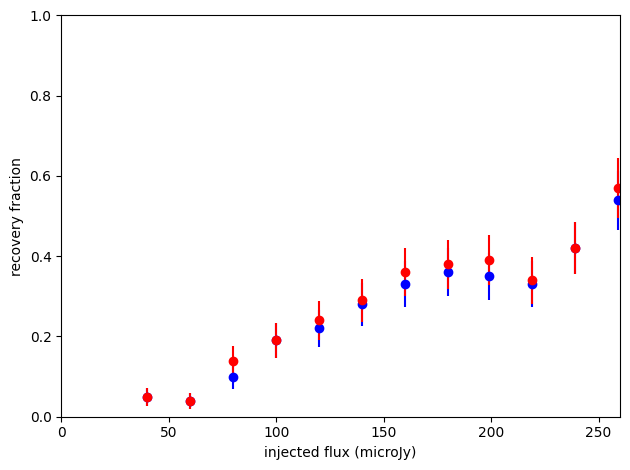

In [11]:
# plot the profiles
fig, ax = plt.subplots()
ax.errorbar(Fcpd, frec_A, yerr=efrec_A, marker='o', color='b', ls='none',
            capsize=0.0, elinewidth=1.5)
ax.errorbar(Fcpd, frec_B, yerr=efrec_B, marker='o', color='r', ls='none',
            capsize=0.0, elinewidth=1.5)
ax.set_xlim([0, 260])
ax.set_ylim([0, 1.0])
ax.set_xlabel('injected flux (microJy)')
ax.set_ylabel('recovery fraction')
fig.tight_layout()
os.makedirs('assess_figs', exist_ok=True)
fig.savefig('assess_figs/'+target+'_recovery_profiles.png')

# show inline in the notebook
plt.show()

# optional: close to avoid duplicate displays later
plt.close(fig)

### Flux recovery bias

In [ ]:
resid_F = Fr - Fi
mu_A, sig_A = np.zeros_like(Fcpd), np.zeros_like(Fcpd)
mu_B, sig_B = np.zeros_like(Fcpd), np.zeros_like(Fcpd)
for i in range(len(Fcpd)):
    mu_A[i]  = np.average(resid_F[(Fi == Fcpd[i]) & is_recovered_A])
    sig_A[i] = np.std(resid_F[(Fi == Fcpd[i]) & is_recovered_A])
    mu_B[i]  = np.average(resid_F[(Fi == Fcpd[i]) & is_recovered_B])
    sig_B[i] = np.std(resid_F[(Fi == Fcpd[i]) & is_recovered_B])


In [ ]:
# measured residual mean and dispersion in high-recovery flux bins
rec_clip = 0.8
print(' ')
print(('mean flux bias when recovery fraction >= %.1f:' % (rec_clip)))
print('----------------------------------------------')
print(('crit A:  %.1f +/- %.1f   (background = %.1f +/- %.1f)' % \
      (np.mean(mu_A[frec_A >= rec_clip]), np.mean(sig_A[frec_A >= rec_clip]),
       np.mean(mu[Fi >= np.min(Fcpd[frec_A >= rec_clip])]),
       np.mean(rms[Fi >= np.min(Fcpd[frec_A >= rec_clip])]))))
print(('crit B:  %.1f +/- %.1f   (background = %.1f +/- %.1f)' % \
      (np.mean(mu_B[frec_B >= rec_clip]), np.mean(sig_B[frec_B >= rec_clip]),
       np.mean(mu[Fi >= np.min(Fcpd[frec_B >= rec_clip])]), 
       np.mean(rms[Fi >= np.min(Fcpd[frec_B >= rec_clip])]))))
print(' ')

In [ ]:
# plot
fig, ax = plt.subplots()
ax.errorbar(Fcpd, mu_A, yerr=sig_A, color='b', ls='none', marker='o', 
            capsize=0.0)
ax.errorbar(Fcpd, mu_B, yerr=sig_B, color='r', ls='none', marker='o',
            capsize=0.0)
ax.plot([0, 260], [0, 0], ':k')
ax.set_xlim([0, 260])
ax.set_ylim([-100, 100])
fig.savefig('assess_figs/'+target+'_Fbias.png')
# show inline in the notebook
plt.show()


it answers “when I inject a CPD of flux , how much does my recovered flux differ on average, and how noisy is that difference?”

In [ ]:
### Identify the non-CPD peak in the search annulus

# isolate the unsuccessful recoveries
FnA, rnA, aznA = Fr[~is_recovered_A], rr[~is_recovered_A], azr[~is_recovered_A]
FnB, rnB, aznB = Fr[~is_recovered_B], rr[~is_recovered_B], azr[~is_recovered_B]

# combine these into arrays
fails_A = np.stack((FnA, rnA, aznA), axis=-1)
valsA, ctsA = np.unique(fails_A, return_counts=True, axis=0)
fails_B = np.stack((FnB, rnB, aznB), axis=-1)
valsB, ctsB = np.unique(fails_B, return_counts=True, axis=0)

print('most common failed recovery parameters: ')
print('----------------------------------------')
nfailsA, nfailsB = 0, 0
for i in range(1,6):
    fails_Ao, nctsA = valsA[ctsA == np.sort(ctsA)[-i]][0], np.sort(ctsA)[-i]
    xd = fails_Ao[1] * np.cos(np.radians(fails_Ao[2]))
    yd = fails_Ao[1] * np.sin(np.radians(fails_Ao[2]))
    xs =  xd * np.cos(PAr) * np.cos(inclr) + yd * np.sin(PAr)
    ys = -xd * np.sin(PAr) * np.cos(inclr) + yd * np.cos(PAr)
    DR = np.sqrt(xs**2 + ys**2)
    DT = 90 - np.degrees(np.arctan2(ys, xs))
    print(('crit A: F = %i, r = %.3f, az = %i, rho=%.3f, PA = %i  (N = %i) ' % \
          (fails_Ao[0], fails_Ao[1], fails_Ao[2], DR, DT, nctsA)))
    nfailsA += nctsA
print(('fraction of crit A fails = %.2f' % (1.*nfailsA / len(FnA))))
print(' ')
for i in range(1, 6):
    fails_Bo, nctsB = valsB[ctsB == np.sort(ctsB)[-i]][0], np.sort(ctsB)[-i]
    xd = fails_Bo[1] * np.cos(np.radians(fails_Bo[2]))
    yd = fails_Bo[1] * np.sin(np.radians(fails_Bo[2]))
    xs =  xd * np.cos(PAr) * np.cos(inclr) + yd * np.sin(PAr)
    ys = -xd * np.sin(PAr) * np.cos(inclr) + yd * np.cos(PAr)
    DR = np.sqrt(xs**2 + ys**2)
    DT = 90 - np.degrees(np.arctan2(ys, xs))
    print(('crit B: F = %i, r = %.3f, az = %i, rho=%.3f, PA =%i  (N = %i) ' % \
          (fails_Bo[0], fails_Bo[1], fails_Bo[2], DR, DT, nctsB)))
    nfailsB += nctsB
print(('fraction of crit B fails = %.2f' % (1.*nfailsB / len(FnB))))
print(' ')

When my injected CPD is not recovered, where does the algorithm tend to pick a different peak instead?
when injections land near that azimuth, recovery fails more often.